# Houlsby + Pfeiffer Adapter 交互教学

配套 lecture: [../lectures/01-houlsby-pfeiffer.md](../lectures/01-houlsby-pfeiffer.md)

本 notebook 演示:
1. Houlsby 双串联 Adapter 结构
2. Pfeiffer 单 Adapter 简化
3. up 层零初始化 → forward = base 强一致性
4. minimal vs adapters 库参数量完美匹配
5. mini training: Houlsby vs Pfeiffer 双方对比

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from houlsby_minimal import HoulsbyGPT2, HoulsbyAdapter
from pfeiffer_minimal import PfeifferGPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 参数布局对比

In [2]:
torch.manual_seed(42)
h = HoulsbyGPT2(r=16)
p = PfeifferGPT2(r=16)
print_param_summary(h, 'Houlsby (r=16)')
print_param_summary(p, 'Pfeiffer (r=16)')

n_h = sum(x.numel() for x in h.parameters() if x.requires_grad)
n_p = sum(x.numel() for x in p.parameters() if x.requires_grad)
print(f'\nHoulsby / Pfeiffer 参数比: {n_h / n_p:.2f}x')
print('→ 严格 2:1（Houlsby 每 block 2 个 adapter，Pfeiffer 只 1 个）')


  Houlsby (r=16)
  Total params:       125,048,448
  Trainable params:       608,640  (0.4867%)
  Frozen params:      124,439,808

  Pfeiffer (r=16)
  Total params:       124,744,128
  Trainable params:       304,320  (0.2440%)
  Frozen params:      124,439,808

Houlsby / Pfeiffer 参数比: 2.00x
→ 严格 2:1（Houlsby 每 block 2 个 adapter，Pfeiffer 只 1 个）


## 2. 初始 forward = base 强一致性

In [3]:
from transformers import GPT2LMHeadModel
base = GPT2LMHeadModel.from_pretrained('gpt2').eval()
h.eval(); p.eval()
tok = h.tokenizer
enc = tok('hello world this is a test', return_tensors='pt', padding=True)

with torch.no_grad():
    o_h = h(enc['input_ids'], enc['attention_mask'])
    o_p = p(enc['input_ids'], enc['attention_mask'])
    o_b = base(enc['input_ids'], attention_mask=enc['attention_mask'])

print(f'Houlsby vs base  max|Δ|: {(o_h.logits - o_b.logits).abs().max():.4e}')
print(f'Pfeiffer vs base max|Δ|: {(o_p.logits - o_b.logits).abs().max():.4e}')
print('\n→ 两者初始 forward 与原始 GPT-2 完全一致（up 层零初始化）')

Houlsby vs base  max|Δ|: 0.0000e+00
Pfeiffer vs base max|Δ|: 0.0000e+00

→ 两者初始 forward 与原始 GPT-2 完全一致（up 层零初始化）


## 3. 与 adapters 库对照（参数量完美匹配）

In [4]:
from houlsby_adapters import build_houlsby_model
from pfeiffer_adapters import build_pfeiffer_model

lib_h = build_houlsby_model(reduction_factor=48)
lib_p = build_pfeiffer_model(reduction_factor=48)

n_lh = sum(x.numel() for x in lib_h.parameters() if x.requires_grad)
n_lp = sum(x.numel() for x in lib_p.parameters() if x.requires_grad)

print(f'{"方法":<10}{"minimal":>12}{"adapters 库":>14}{"diff":>8}')
print('-' * 50)
print(f'{"Houlsby":<10}{n_h:>12,}{n_lh:>14,}{abs(n_h-n_lh):>8}')
print(f'{"Pfeiffer":<10}{n_p:>12,}{n_lp:>14,}{abs(n_p-n_lp):>8}')

W0603 16:52:00.850000 41660 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


There are adapters available but none are activated for the forward pass.


There are adapters available but none are activated for the forward pass.


方法             minimal    adapters 库    diff
--------------------------------------------------
Houlsby        608,640       608,640       0
Pfeiffer       304,320       304,320       0


## 4. mini training: Houlsby vs Pfeiffer

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


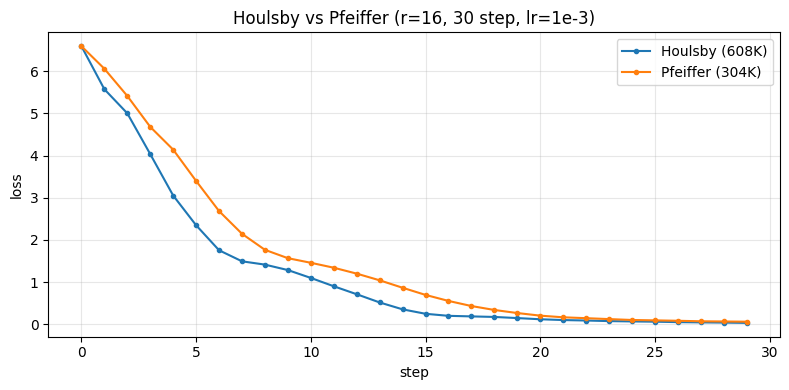

      Houlsby (608K) final loss: 0.0336
     Pfeiffer (304K) final loss: 0.0618


In [5]:
torch.manual_seed(42)
houlsby = HoulsbyGPT2(r=16)
torch.manual_seed(42)
pfeiffer = PfeifferGPT2(r=16)

tok = houlsby.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
    'absolutely terrible movie',
    'fantastic experience from start to finish'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('Houlsby (608K)', houlsby, torch.optim.AdamW([p for p in houlsby.parameters() if p.requires_grad], lr=1e-3)),
    ('Pfeiffer (304K)', pfeiffer, torch.optim.AdamW([p for p in pfeiffer.parameters() if p.requires_grad], lr=1e-3)),
]

losses = {n: [] for n, _, _ in models}
for step in range(30):
    for name, m, opt in models:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
for n in losses:
    plt.plot(losses[n], label=n, marker='o', markersize=3)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Houlsby vs Pfeiffer (r=16, 30 step, lr=1e-3)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
for n in losses:
    print(f'{n:>20} final loss: {losses[n][-1]:.4f}')

## 5. 思考题

1. 如果把 GELU 替换为 ReLU，会对训练动态有什么影响？
2. Houlsby 的 attn-后 adapter 输入是什么？FFN-后 adapter 又是什么？两者梯度感受野有差异吗？
3. 跑一下 r=4 vs r=64 的对比，参数量和收敛速度的 trade-off 怎么样？

下节: **AdapterFusion** — 把训好的 adapter 组合到新任务